# Training and Evaluation

In this notebook we train and evaluate the models. We also generate the plots/metrics needed for the report and presentation.

## Train the model by running the cells below

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

# =========================
# Reproducibility
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)


# =========================
# Manifest + Dataset
# =========================
def load_feature_manifest(manifest_csv: str | Path) -> pd.DataFrame:
    df = pd.read_csv(manifest_csv)
    required = {"utt", "feat_path", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Manifest missing columns: {missing}")
    return df


class FeatureNPYDataset(Dataset):
    def __init__(self, manifest_csv: str | Path):
        self.df = load_feature_manifest(manifest_csv)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat = np.load(row["feat_path"]).astype(np.float32)

        # This training loop expects one vector per utterance.
        # If you later save SSL embeddings with mean/std pooling,
        # they will fit this same format automatically.
        if feat.ndim != 1:
            feat = feat.reshape(-1).astype(np.float32)

        label = np.float32(row["label"])
        utt = str(row["utt"])

        return torch.from_numpy(feat), torch.tensor(label), utt


def infer_input_dim(manifest_csv: str | Path) -> int:
    df = load_feature_manifest(manifest_csv)
    x = np.load(df.iloc[0]["feat_path"]).astype(np.float32)
    if x.ndim != 1:
        x = x.reshape(-1)
    return int(x.shape[0])


# =========================
# Model
# =========================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# =========================
# Metrics
# =========================
def eer_score(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    threshold = _[idx]
    return float(eer), float(threshold)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_prob = [], []

    for x, y, _ in loader:
        x = x.to(DEVICE).float()
        logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()

        y_true.extend(y.numpy().tolist())
        y_prob.extend(prob.tolist())

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)

    eer, thr = eer_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else (float("nan"), 0.5)

    metrics = {
        "eer": eer,
        "threshold_eer": thr,
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    return metrics, y_true, y_prob, y_pred


# =========================
# Data loaders
# =========================
def make_loader(manifest, batch_size: int = 64, num_workers: int = 2):
    ds = FeatureNPYDataset(manifest)

    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return loader


def get_pos_weight(manifest_csv: str | Path) -> torch.Tensor:
    df = load_feature_manifest(manifest_csv)
    y = df["label"].astype(int).values
    n_pos = max(int(y.sum()), 1)
    n_neg = max(int((1 - y).sum()), 1)
    return torch.tensor([n_neg / n_pos], dtype=torch.float32, device=DEVICE)


# =========================
# Train loop
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x, y, _ in loader:
        x = x.to(DEVICE).float()
        y = y.to(DEVICE).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


def train_classifier(
    train_manifest: str | Path,
    dev_manifest: str | Path,
    exp_name: str,
    save_dir: str,
    batch_size: int = 64,
    hidden_dim: int = 256,
    dropout: float = 0.3,
    lr: float = 1e-3,
    epochs: int = 15,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    input_dim = infer_input_dim(train_manifest)
    model = MLPClassifier(input_dim=input_dim, hidden_dim=hidden_dim, dropout=dropout).to(DEVICE)

    train_loader = make_loader(train_manifest,batch_size=batch_size)
    dev_loader = make_loader(dev_manifest,batch_size=batch_size)

    pos_weight = get_pos_weight(train_manifest)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_dev_eer = float("inf")
    best_path = save_dir / f"{exp_name}_best.pt"

    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        dev_metrics, _, _, _ = evaluate(model, dev_loader)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "dev_eer": dev_metrics["eer"],
            "dev_auc": dev_metrics["roc_auc"],
            "dev_acc": dev_metrics["accuracy"],
        }
        history.append(row)

        if dev_metrics["eer"] < best_dev_eer:
            best_dev_eer = dev_metrics["eer"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "input_dim": input_dim,
                    "hidden_dim": hidden_dim,
                    "dropout": dropout,
                    "exp_name": exp_name,
                    "best_dev_eer": best_dev_eer,
                    "feature_type": exp_name,
                },
                best_path,
            )

        print(
            f"[{exp_name}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"dev_EER={dev_metrics['eer']:.4f} | "
            f"dev_AUC={dev_metrics['roc_auc']:.4f} | "
            f"dev_ACC={dev_metrics['accuracy']:.4f}"
        )

    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    

    history_df = pd.DataFrame(history)
    history_path = save_dir / f"{exp_name}_history.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Saved {exp_name} training history to: {history_path}")

    return {
        "model": model,
        "best_checkpoint": best_path,
        "history": history_df,
    }


# =========================
# Load later
# =========================
def load_trained_model(checkpoint_path: str | Path):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model = MLPClassifier(
        input_dim=ckpt["input_dim"],
        hidden_dim=ckpt["hidden_dim"],
        dropout=ckpt["dropout"],
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model

cuda


### Run the training

Train for each of the handcrafted features (MFCC, LFCC, CQCC) and deep embeddings (Wav2Vec, HuBERT). Make sure to plot the results and save after.

In [2]:
PROJECT_DIR = Path("/scratch1/kodachi/p2")
MODELS_DIR = PROJECT_DIR / "models"
FEATURES_DIR = PROJECT_DIR / "features"

# Uncomment which model to run
# exp_name = "cqcc"
# exp_name = "mfcc"
exp_name = "lfcc"
# exp_name = "wav2vec2"
# exp_name = "hubert"

train_manifest = FEATURES_DIR / f"{exp_name}_LA_train_preprocessed_feat_manifest.csv"
dev_manifest = FEATURES_DIR / f"{exp_name}_LA_dev_preprocessed_feat_manifest.csv"
eval_manifest = FEATURES_DIR / f"{exp_name}_LA_eval_preprocessed_feat_manifest.csv"

In [3]:
results = train_classifier(
    train_manifest=train_manifest,
    dev_manifest=dev_manifest,
    save_dir=MODELS_DIR,
    exp_name=exp_name,
    epochs=15,
    batch_size=64,
)

print("Best Checkpoint:")
print(results["best_checkpoint"])

[lfcc] epoch 01 | train_loss=0.0876 | dev_EER=0.0629 | dev_AUC=0.9832 | dev_ACC=0.9562


[lfcc] epoch 02 | train_loss=0.0398 | dev_EER=0.0437 | dev_AUC=0.9917 | dev_ACC=0.9565


[lfcc] epoch 03 | train_loss=0.0251 | dev_EER=0.0429 | dev_AUC=0.9924 | dev_ACC=0.9579


[lfcc] epoch 04 | train_loss=0.0187 | dev_EER=0.0381 | dev_AUC=0.9942 | dev_ACC=0.9694


[lfcc] epoch 05 | train_loss=0.0170 | dev_EER=0.0424 | dev_AUC=0.9937 | dev_ACC=0.9565


...

[lfcc] epoch 11 | train_loss=0.0086 | dev_EER=0.0384 | dev_AUC=0.9944 | dev_ACC=0.9615


[lfcc] epoch 12 | train_loss=0.0088 | dev_EER=0.0421 | dev_AUC=0.9940 | dev_ACC=0.9403


[lfcc] epoch 13 | train_loss=0.0108 | dev_EER=0.0374 | dev_AUC=0.9945 | dev_ACC=0.9303


[lfcc] epoch 14 | train_loss=0.0094 | dev_EER=0.0337 | dev_AUC=0.9960 | dev_ACC=0.9247


[lfcc] epoch 15 | train_loss=0.0099 | dev_EER=0.0290 | dev_AUC=0.9969 | dev_ACC=0.9717
Saved lfcc training history to: /scratch1/kodachi/p2/models/lfcc_history.csv
Best Checkpoint:
/scratch1/kodachi/p2/models/lfcc_best.pt


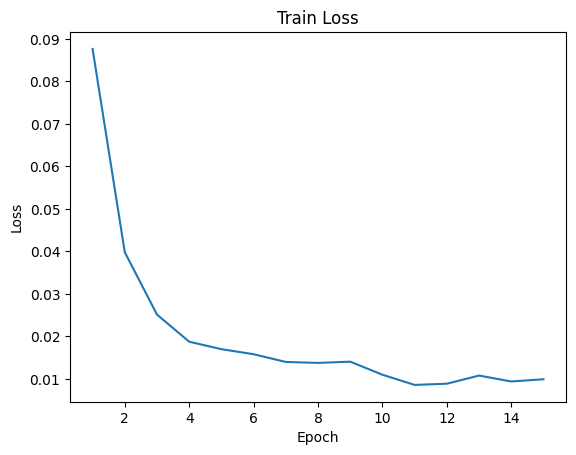

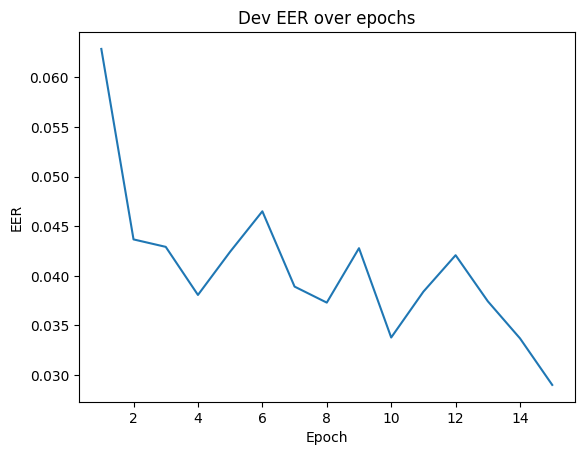

In [4]:
import matplotlib.pyplot as plt

df_path = MODELS_DIR / f"{exp_name}_history.csv"
df = pd.read_csv(df_path)
# df = results['history']

# Plot Loss
plt.plot(df["epoch"], df["train_loss"])
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot EER
plt.plot(df["epoch"], df["dev_eer"])
plt.title("Dev EER over epochs")
plt.xlabel("Epoch")
plt.ylabel("EER")
plt.show()

## Evaluate the Model

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SPOOF_LABEL = 1


# -------------------------
# Model
# -------------------------
class MLPClassifier(torch.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def load_trained_model(checkpoint_path: str | Path):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model = MLPClassifier(
        input_dim=ckpt["input_dim"],
        hidden_dim=ckpt["hidden_dim"],
        dropout=ckpt["dropout"],
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


# -------------------------
# Datasets
# -------------------------
class DevFeatureDataset(Dataset):
    def __init__(self, manifest_csv: str | Path):
        self.df = pd.read_csv(manifest_csv)
        required = {"utt", "feat_path", "label"}
        missing = required - set(self.df.columns)
        if missing:
            raise ValueError(f"Dev manifest missing columns: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(row["feat_path"]).astype(np.float32)
        if x.ndim != 1:
            x = x.reshape(-1).astype(np.float32)

        y = int(row["label"])
        utt = str(row["utt"])
        return torch.from_numpy(x), torch.tensor(y), utt


class EvalFeatureDataset(Dataset):
    def __init__(self, manifest_csv: str | Path):
        self.df = pd.read_csv(manifest_csv)
        required = {"utt", "feat_path", "label", "attack_type"}
        missing = required - set(self.df.columns)
        if missing:
            raise ValueError(f"Eval manifest missing columns: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(row["feat_path"]).astype(np.float32)
        if x.ndim != 1:
            x = x.reshape(-1).astype(np.float32)

        y = int(row["label"])
        attack_type = str(row["attack_type"])
        utt = str(row["utt"])
        return torch.from_numpy(x), torch.tensor(y), attack_type, utt


# -------------------------
# Metrics
# -------------------------
def eer_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    threshold = thr[idx]
    return float(eer), float(threshold)


def add_predictions(df, threshold: float):
    out = df.copy()
    out["pred"] = (out["prob"] >= threshold).astype(int)
    out["correct"] = (out["pred"] == out["label"]).astype(int)
    return out


# -------------------------
# Dev scoring
# -------------------------
@torch.no_grad()
def score_dev_manifest(model, manifest_csv: str | Path, batch_size: int = 64):
    ds = DevFeatureDataset(manifest_csv)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    rows = []
    for x, y, utt in loader:
        x = x.to(DEVICE).float()
        logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()

        y = y.numpy().tolist()
        utt = list(utt)

        for i in range(len(y)):
            rows.append(
                {
                    "utt": utt[i],
                    "label": int(y[i]),
                    "prob": float(prob[i]),
                }
            )

    return pd.DataFrame(rows)


# -------------------------
# Eval scoring
# -------------------------
@torch.no_grad()
def score_eval_manifest(model, manifest_csv: str | Path, batch_size: int = 64):
    ds = EvalFeatureDataset(manifest_csv)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    rows = []
    for x, y, attack_type, utt in loader:
        x = x.to(DEVICE).float()
        logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()

        y = y.numpy().tolist()
        attack_type = list(attack_type)
        utt = list(utt)

        for i in range(len(y)):
            rows.append(
                {
                    "utt": utt[i],
                    "label": int(y[i]),
                    "prob": float(prob[i]),
                    "attack_type": attack_type[i],
                }
            )

    return pd.DataFrame(rows)


# -------------------------
# Plot misclassified attacks
# -------------------------
def plot_misclassified_attacks(df, spoof_label: int = SPOOF_LABEL, attack_col: str = "attack_type"):
    if attack_col not in df.columns:
        raise ValueError("attack_type column not found.")

    mis = df[(df["label"] == spoof_label) & (df["pred"] != spoof_label)].copy()
    spoof_only = df[df["label"] == spoof_label].copy()

    counts = mis[attack_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(11, 5))
    counts.plot(kind="bar")
    plt.title("Misclassified attack types (count)")
    plt.xlabel("Attack type")
    plt.ylabel("Number of spoof trials predicted as bonafide")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    total_per_attack = spoof_only.groupby(attack_col).size()
    mis_per_attack = mis.groupby(attack_col).size()
    rate = (mis_per_attack / total_per_attack).fillna(0.0).sort_values(ascending=False)

    plt.figure(figsize=(11, 5))
    rate.plot(kind="bar")
    plt.title("Misclassified attack types (rate)")
    plt.xlabel("Attack type")
    plt.ylabel("Misclassification rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return counts, rate, mis

### Evaluate each model

Run each model against the eval set for the final metrics

In [6]:
model_path = MODELS_DIR / f"{exp_name}_best.pt"
model = load_trained_model(model_path)
# model = load_trained_model("models/mfcc_best.pt")

In [7]:
dev_scores = score_dev_manifest(model, dev_manifest)
dev_eer, dev_thr = eer_threshold(dev_scores["label"].values, dev_scores["prob"].values)
dev_scores = add_predictions(dev_scores, dev_thr)

print("DEV EER:", dev_eer)
print("DEV AUC:", roc_auc_score(dev_scores["label"].values, dev_scores["prob"].values))
print("DEV ACC:", accuracy_score(dev_scores["label"].values, dev_scores["pred"].values))

DEV EER: 0.029008096573066564
DEV AUC: 0.9968755615188031
DEV ACC: 0.9710191595556271


In [8]:
eval_scores = score_eval_manifest(model, eval_manifest)
eval_scores = add_predictions(eval_scores, dev_thr)

eval_eer, _ = eer_threshold(eval_scores["label"].values, eval_scores["prob"].values)
print("EVAL EER:", eval_eer)
print("EVAL AUC:", roc_auc_score(eval_scores["label"].values, eval_scores["prob"].values))
print("EVAL ACC:", accuracy_score(eval_scores["label"].values, eval_scores["pred"].values))

EVAL EER: 0.17673347790222754
EVAL AUC: 0.9017582458020674
EVAL ACC: 0.6437244690259275


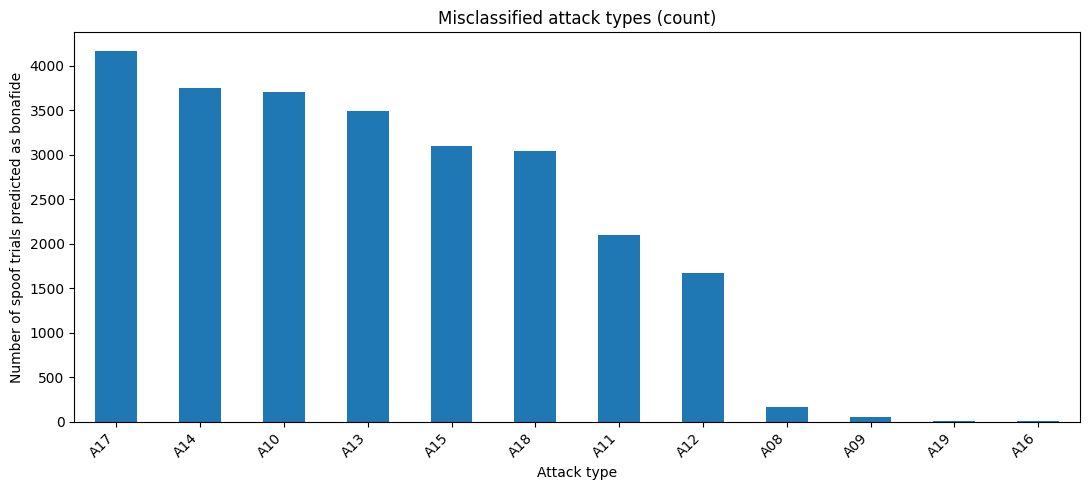

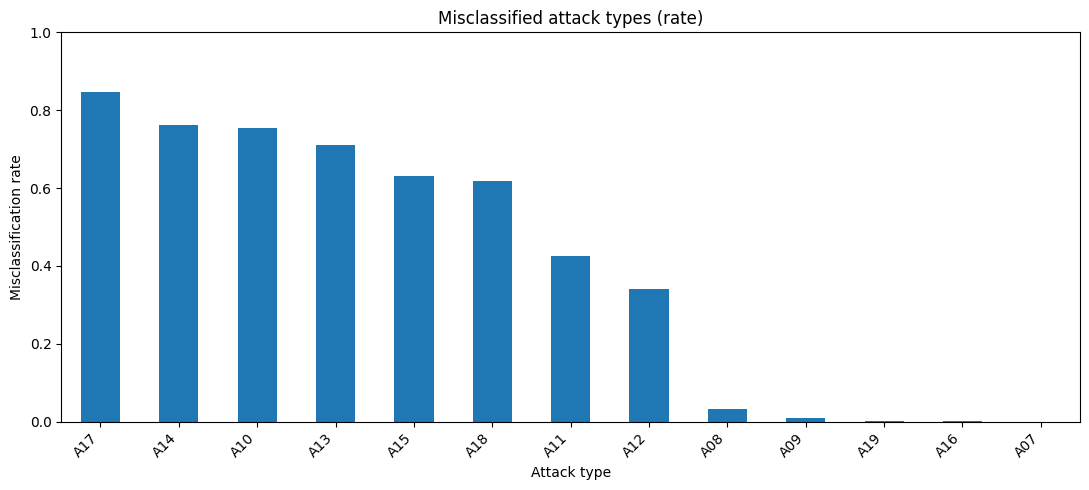

(attack_type
 A17    4166
 A14    3747
 A10    3704
 A13    3486
 A15    3097
 A18    3041
 A11    2096
 A12    1675
 A08     162
 A09      51
 A19       5
 A16       3
 Name: count, dtype: int64,
 attack_type
 A17    0.847782
 A14    0.762515
 A10    0.753765
 A13    0.709402
 A15    0.630240
 A18    0.618844
 A11    0.426536
 A12    0.340863
 A08    0.032967
 A09    0.010379
 A19    0.001018
 A16    0.000611
 A07    0.000000
 dtype: float64,
                 utt  label      prob attack_type  pred  correct
 0      LA_E_2834763      1  0.000200         A11     0        0
 1      LA_E_8877452      1  0.341342         A14     0        0
 4      LA_E_5932896      1  0.073498         A13     0        0
 10     LA_E_1611480      1  0.000029         A13     0        0
 12     LA_E_1781840      1  0.066173         A15     0        0
 ...             ...    ...       ...         ...   ...      ...
 71214  LA_E_9547535      1  0.000871         A13     0        0
 71215  LA_E_8488489      1  0.0

In [9]:
plot_misclassified_attacks(eval_scores)